In [6]:
# LIBRERÍAS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

### DATASETS

In [7]:
behavioural = pd.read_csv( "/home/jovyan/work/data/BEHAVIOURAL.csv")
behavioural.head()

,CONTRACT_ID,CLIENT_ID,DATE,CREDICT_CARD_BALANCE,CREDIT_CARD_LIMIT,CREDIT_CARD_DRAWINGS_ATM,CREDIT_CARD_DRAWINGS,CREDIT_CARD_DRAWINGS_POS,CREDIT_CARD_DRAWINGS_OTHER,CREDIT_CARD_PAYMENT,NUMBER_DRAWINGS_ATM,NUMBER_DRAWINGS,NUMBER_INSTALMENTS,CURRENCY
0,ES1821000018d00XXX,ES182394447V,2021-08-29,491.21,540.0,0.0,28.03,28.03,0.0,46.81,0.0,2,1.0,euros
1,ES1821000018d00XXX,ES182394447V,2021-07-29,466.55,540.0,162.0,612.51,450.51,0.0,108.00,3.0,15,0.0,euros
2,ES1821000018d00XXX,ES182394447V,2021-11-30,1640.35,1620.0,0.0,273.93,273.93,0.0,95.65,0.0,11,4.0,euros
3,ES1821000018d00XXX,ES182394447V,2021-10-30,1366.35,1620.0,162.0,829.88,667.88,0.0,38.29,3.0,14,3.0,euros
4,ES1821000018d00XXX,ES182394447V,2021-09-29,532.33,540.0,0.0,24.39,24.39,0.0,43.76,0.0,2,2.0,euros


In [8]:
# Seleccionar columnas numéricas
behavioural_num = behavioural.select_dtypes(include=['int64', 'float64'])

# Seleccionar columnas categóricas
behavioural_cat = behavioural.select_dtypes(include=['object', 'category'])

In [9]:
clientes = pd.read_csv("/home/jovyan/work/data/CLIENTS.csv")
clientes.head()

,CLIENT_ID,NON_COMPLIANT_CONTRACT,NAME_PRODUCT_TYPE,GENDER,TOTAL_INCOME,AMOUNT_PRODUCT,INSTALLMENT,EDUCATION,MARITAL_STATUS,HOME_SITUATION,...,LOAN_CREDIT_GRANTED_MAX,LOAN_CREDIT_GRANTED_MIN,LOAN_CREDIT_GRANTED_SUM,LOAN_VARIABLE_RATE_MAX,LOAN_VARIABLE_RATE_MIN,NUM_STATUS_ANNULLED,NUM_STATUS_AUTHORIZED,NUM_STATUS_DENIED,NUM_STATUS_NOT_USED,NUM_FLAG_INSURED
0,ES182411319L,0,PRODUCT 1,M,1350.0,6495.88,276.75,Primary School,Married,Living with relative,...,2445.12,316.82,4248.18,0.592495,0.0,0.0,5.0,0.0,0.0,3.0
1,ES182116369S,0,PRODUCT 1,F,918.0,8100.00,261.31,Secondary,Married,House,...,895.48,0.00,895.48,0.000000,0.0,1.0,1.0,0.0,0.0,0.0
2,ES182154395P,0,PRODUCT 1,M,1350.0,3234.60,298.24,Secondary,Single,House,...,731.70,352.84,1624.54,0.108909,0.0,0.0,3.0,0.0,0.0,1.0
3,ES182369450D,0,PRODUCT 1,F,1620.0,4890.24,386.37,Secondary,Single,House,...,1205.98,899.05,2105.03,0.000000,0.0,0.0,2.0,0.0,0.0,1.0
4,ES182116792X,0,PRODUCT 1,F,2430.0,5004.29,242.30,Secondary,Married,House,...,2160.00,2160.00,2160.00,0.000000,0.0,0.0,1.0,0.0,0.0,1.0


### ANALISIS CLIENTES

In [10]:
# Seleccionar columnas numéricas
clientes_num = clientes.select_dtypes(include=['int64', 'float64'])

# Seleccionar columnas categóricas
clientes_cat = clientes.select_dtypes(include=['object', 'category'])

In [11]:
def calcular_estadisticos(clientes):
    
    # Preparar diccionario para el resumen
    resumen = {
        "Columna": [],
        "Media": [],
        "Mediana": [],
        "Moda": [],
        "Min": [],
        "Max": [],
        "Rango": [],
        "Varianza": [],
        "DesvStd": [],
        "CoefVar": []
    }
    
    # Recorrer cada columna numérica
    for col in clientes_num.columns:
        
        serie = clientes_num[col]
        
        media = serie.mean()
        mediana = serie.median()
        moda = serie.mode().iloc[0] if not serie.mode().empty else None
        
        minimo = serie.min()
        maximo = serie.max()
        rango = maximo - minimo
        
        varianza = serie.var()
        desv_std = serie.std()
        coef_var = desv_std / media if media != 0 else None
        
        # Guardar en resumen
        resumen["Columna"].append(col)
        resumen["Media"].append(media)
        resumen["Mediana"].append(mediana)
        resumen["Moda"].append(moda)
        resumen["Min"].append(minimo)
        resumen["Max"].append(maximo)
        resumen["Rango"].append(rango)
        resumen["Varianza"].append(varianza)
        resumen["DesvStd"].append(desv_std)
        resumen["CoefVar"].append(coef_var)
        
    
    # Convertir a DataFrame
    resumen_clientes = pd.DataFrame(resumen)
    
    return resumen_clientes

In [12]:
resultado_estadisticos = calcular_estadisticos(clientes)

# Mostrar el DataFrame resumen
display(resultado_estadisticos)

,Columna,Media,Mediana,Moda,Min,Max,Rango,Varianza,DesvStd,CoefVar
0,NON_COMPLIANT_CONTRACT,0.081214,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,7.461867e-02,0.273164,3.363515
1,TOTAL_INCOME,2029.338959,1782.000000,1620.000000,307.800000,1.404000e+06,1.403692e+06,1.385700e+07,3722.499128,1.834341
2,AMOUNT_PRODUCT,7193.391443,6162.370000,5400.000000,540.000000,4.848619e+04,4.794619e+04,2.334373e+07,4831.534717,0.671663
3,INSTALLMENT,325.583354,299.160000,108.000000,19.390000,2.898155e+03,2.878765e+03,3.009444e+04,173.477501,0.532821
4,REGION_SCORE,0.020516,0.018850,0.035792,0.000533,5.936400e-02,5.883100e-02,1.587582e-04,0.012600,0.614146
5,AGE_IN_YEARS,43.951931,43.200000,52.838356,20.517808,6.908219e+01,4.856438e+01,1.423527e+02,11.931164,0.271459
6,JOB_SENIORITY,2398.921459,1650.000000,199.000000,1.000000,1.772900e+04,1.772800e+04,5.571939e+06,2360.495553,0.983982
7,HOME_SENIORITY,4987.488180,4508.000000,6.000000,0.000000,2.404400e+04,2.404400e+04,1.239685e+07,3520.915689,0.705950
8,LAST_UPDATE,2992.176141,3254.000000,4285.000000,0.000000,6.874000e+03,6.874000e+03,2.280752e+06,1510.215965,0.504722
9,CAR_AGE,11.987407,9.000000,7.000000,0.000000,6.450000e+01,6.450000e+01,1.392278e+02,11.799483,0.984323


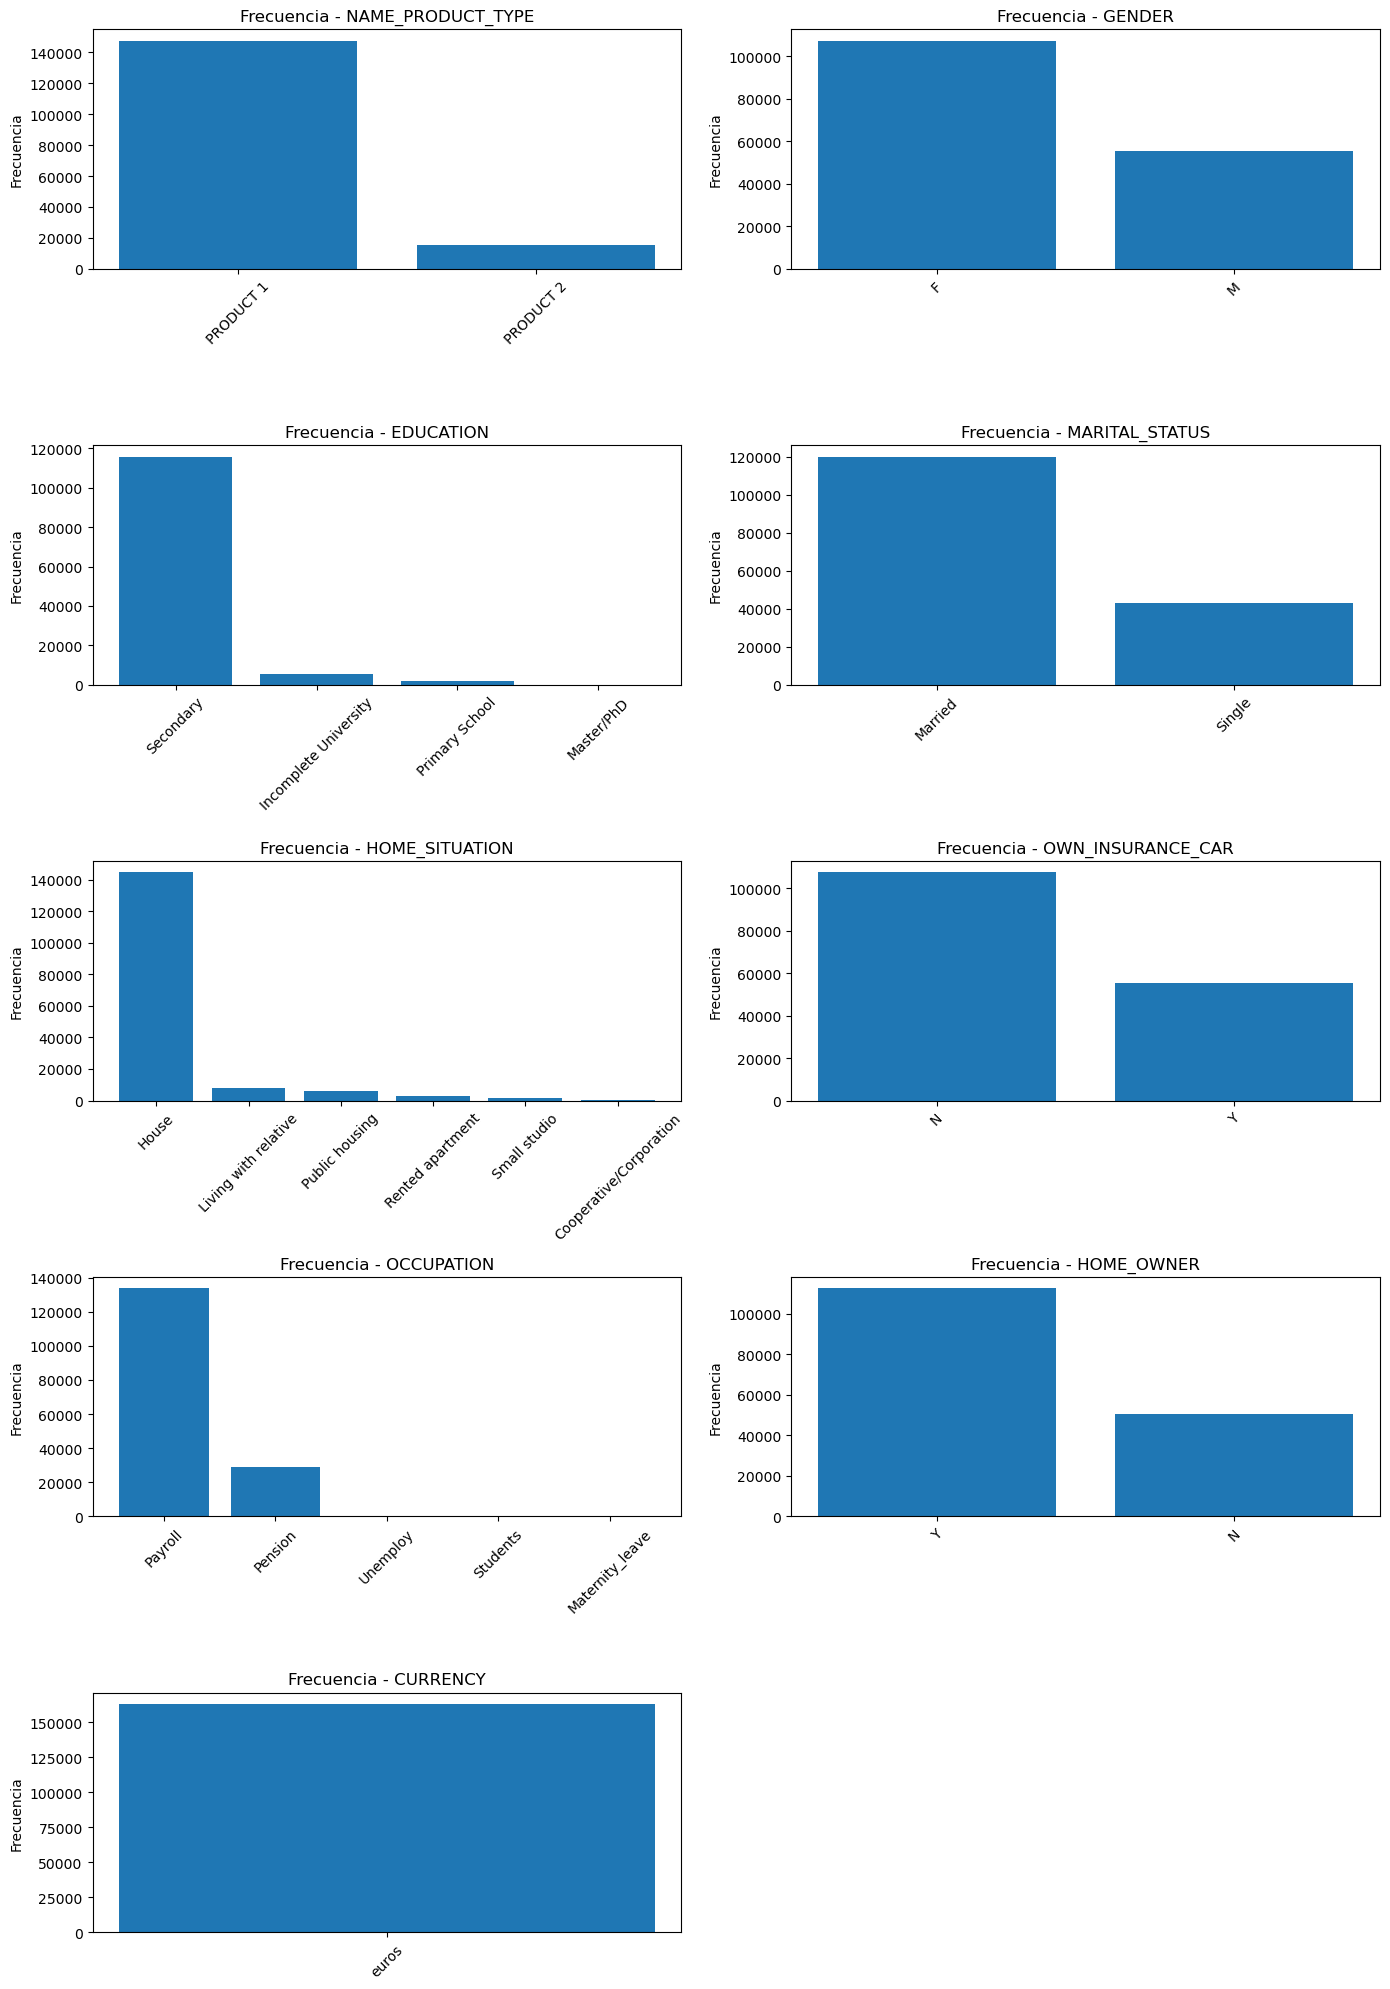

In [13]:
# Filtrar columnas categóricas con pocas categorías
columnas_validas = [col for col in clientes_cat.columns if clientes_cat[col].nunique() <= 20]

n = len(columnas_validas)
cols = 2                       # 2 gráficos por fila
rows = math.ceil(n / cols)     # número de filas necesarias

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()          # aplanar para indexar fácilmente

for i, col in enumerate(columnas_validas):
    conteo = clientes_cat[col].value_counts()
    
    axes[i].bar(conteo.index, conteo.values)
    axes[i].set_title(f"Frecuencia - {col}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("Frecuencia")

# Si sobran subplots vacíos, los apagamos
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
plt.close()



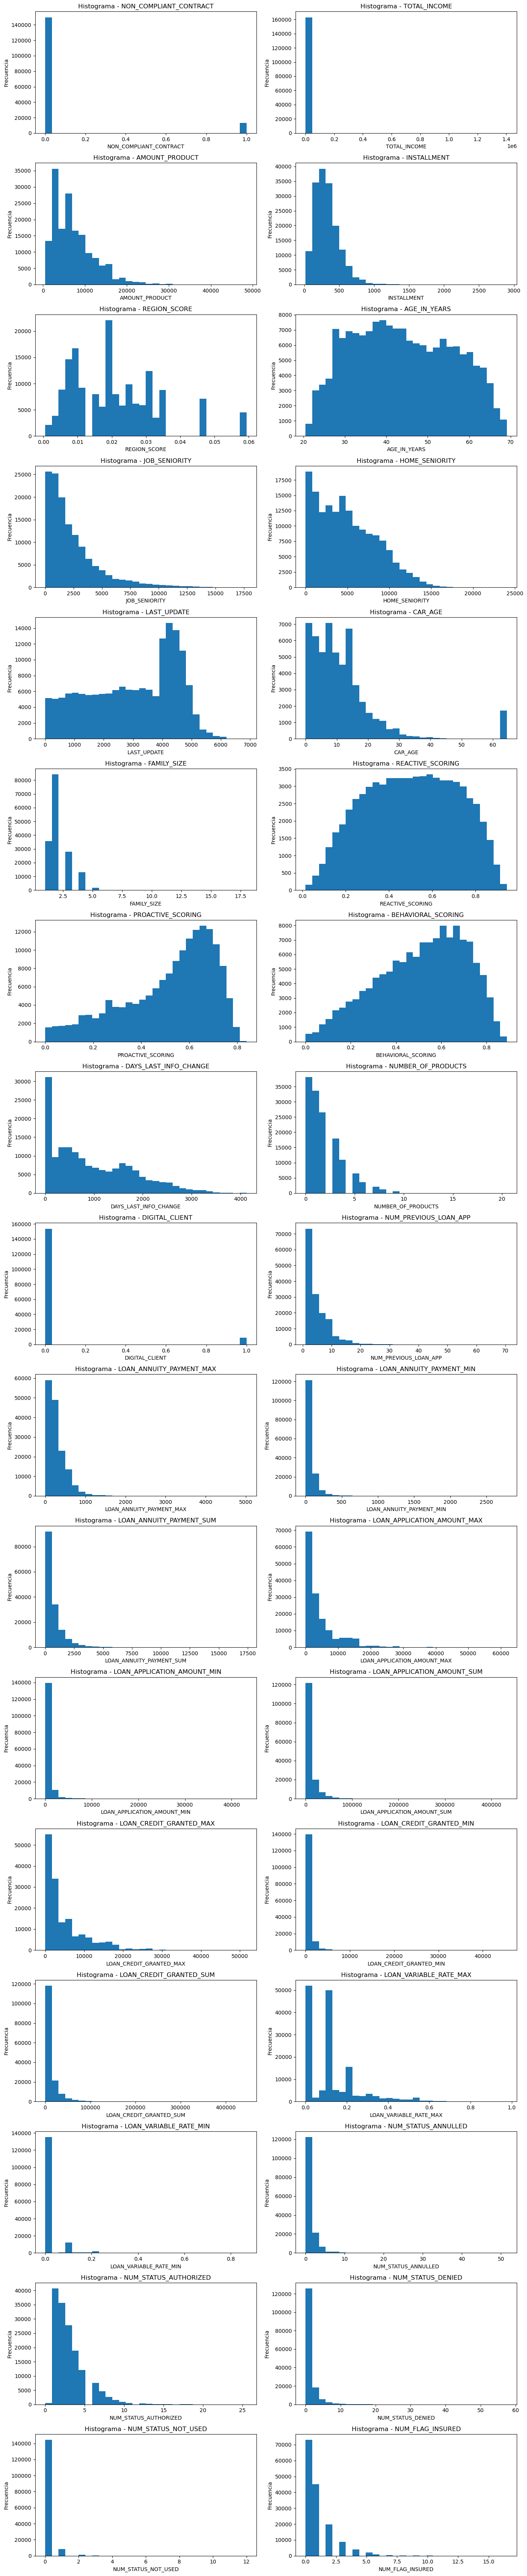

In [14]:
# Frecuencia de variables numéricas (histogramas)
columnas = clientes_num.columns
n = len(columnas)
cols = 2                      # 2 gráficos por fila
rows = math.ceil(n / cols)    # número de filas necesarias

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()         # aplanar matriz de ejes

for i, col in enumerate(columnas):
    axes[i].hist(clientes_num[col], bins=30)
    axes[i].set_title(f"Histograma - {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Apagar ejes vacíos si sobran
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
plt.close()

### CORRELACIONANDO CLIENTS CON BEHAVIOURAL

Dado que ambos datasets tienen en comúm CLIENTES_ID, unificamos ambos DataSets por esa variable.

In [15]:
# Unir ambos datasets por CLIENT_ID
cli_y_beh = behavioural.merge(clientes, on="CLIENT_ID", how="inner")

In [16]:
cli_y_beh_num = cli_y_beh.select_dtypes(include=['int64', 'float64'])

In [17]:
corr_matrix = cli_y_beh_num.corr()

In [18]:
corr_matrix

,CREDICT_CARD_BALANCE,CREDIT_CARD_LIMIT,CREDIT_CARD_DRAWINGS_ATM,CREDIT_CARD_DRAWINGS,CREDIT_CARD_DRAWINGS_POS,CREDIT_CARD_DRAWINGS_OTHER,CREDIT_CARD_PAYMENT,NUMBER_DRAWINGS_ATM,NUMBER_DRAWINGS,NUMBER_INSTALMENTS,...,LOAN_CREDIT_GRANTED_MAX,LOAN_CREDIT_GRANTED_MIN,LOAN_CREDIT_GRANTED_SUM,LOAN_VARIABLE_RATE_MAX,LOAN_VARIABLE_RATE_MIN,NUM_STATUS_ANNULLED,NUM_STATUS_AUTHORIZED,NUM_STATUS_DENIED,NUM_STATUS_NOT_USED,NUM_FLAG_INSURED
CREDICT_CARD_BALANCE,1.000000,0.502851,0.297704,0.338085,0.180017,0.068839,0.170358,0.330442,0.259991,0.035992,...,0.091773,0.007229,0.082795,-0.030765,-0.041391,0.038205,0.011098,0.052171,-0.016643,0.005105
CREDIT_CARD_LIMIT,0.502851,1.000000,0.204303,0.270701,0.198381,0.042330,0.243413,0.181497,0.212744,-0.127986,...,0.164609,0.002503,0.126757,0.011417,-0.060350,0.054534,0.072052,0.018762,-0.014580,0.000367
CREDIT_CARD_DRAWINGS_ATM,0.297704,0.204303,1.000000,0.813612,0.088916,0.019076,0.179762,0.735354,0.308227,-0.071134,...,0.049176,-0.003340,0.043486,-0.006648,-0.016949,0.031109,0.012550,0.019414,-0.006731,0.000588
CREDIT_CARD_DRAWINGS,0.338085,0.270701,0.813612,1.000000,0.602822,0.241482,0.303970,0.607439,0.526878,-0.094927,...,0.059775,-0.005097,0.050617,-0.004594,-0.021160,0.045074,0.010071,0.020868,-0.005475,-0.019368
CREDIT_CARD_DRAWINGS_POS,0.180017,0.198381,0.088916,0.602822,1.000000,0.009370,0.294566,0.083150,0.538200,-0.067656,...,0.036476,-0.004202,0.027235,0.000914,-0.014512,0.037097,-0.000704,0.008048,0.000249,-0.036531
CREDIT_CARD_DRAWINGS_OTHER,0.068839,0.042330,0.019076,0.241482,0.009370,1.000000,0.024187,0.012822,0.023441,-0.020800,...,0.011568,-0.000872,0.012399,-0.000139,-0.002108,0.006599,0.002943,0.007792,-0.001935,-0.001735
CREDIT_CARD_PAYMENT,0.170358,0.243413,0.179762,0.303970,0.294566,0.024187,1.000000,0.145319,0.224442,-0.006516,...,0.065707,0.004508,0.055868,-0.005242,-0.018673,0.033428,0.012163,0.020895,-0.005646,-0.006622
NUMBER_DRAWINGS_ATM,0.330442,0.181497,0.735354,0.607439,0.083150,0.012822,0.145319,1.000000,0.422501,-0.054099,...,0.028534,-0.008648,0.028571,-0.016386,-0.021304,0.027862,0.011497,0.024080,-0.008131,0.008866
NUMBER_DRAWINGS,0.259991,0.212744,0.308227,0.526878,0.538200,0.023441,0.224442,0.422501,1.000000,-0.087439,...,0.015320,-0.019678,0.015903,-0.013923,-0.022293,0.054394,0.000814,0.018757,-0.000502,-0.034507
NUMBER_INSTALMENTS,0.035992,-0.127986,-0.071134,-0.094927,-0.067656,-0.020800,-0.006516,-0.054099,-0.087439,1.000000,...,0.017844,0.068041,0.004740,-0.077116,0.010462,-0.034051,-0.078292,0.011039,-0.018582,0.046205


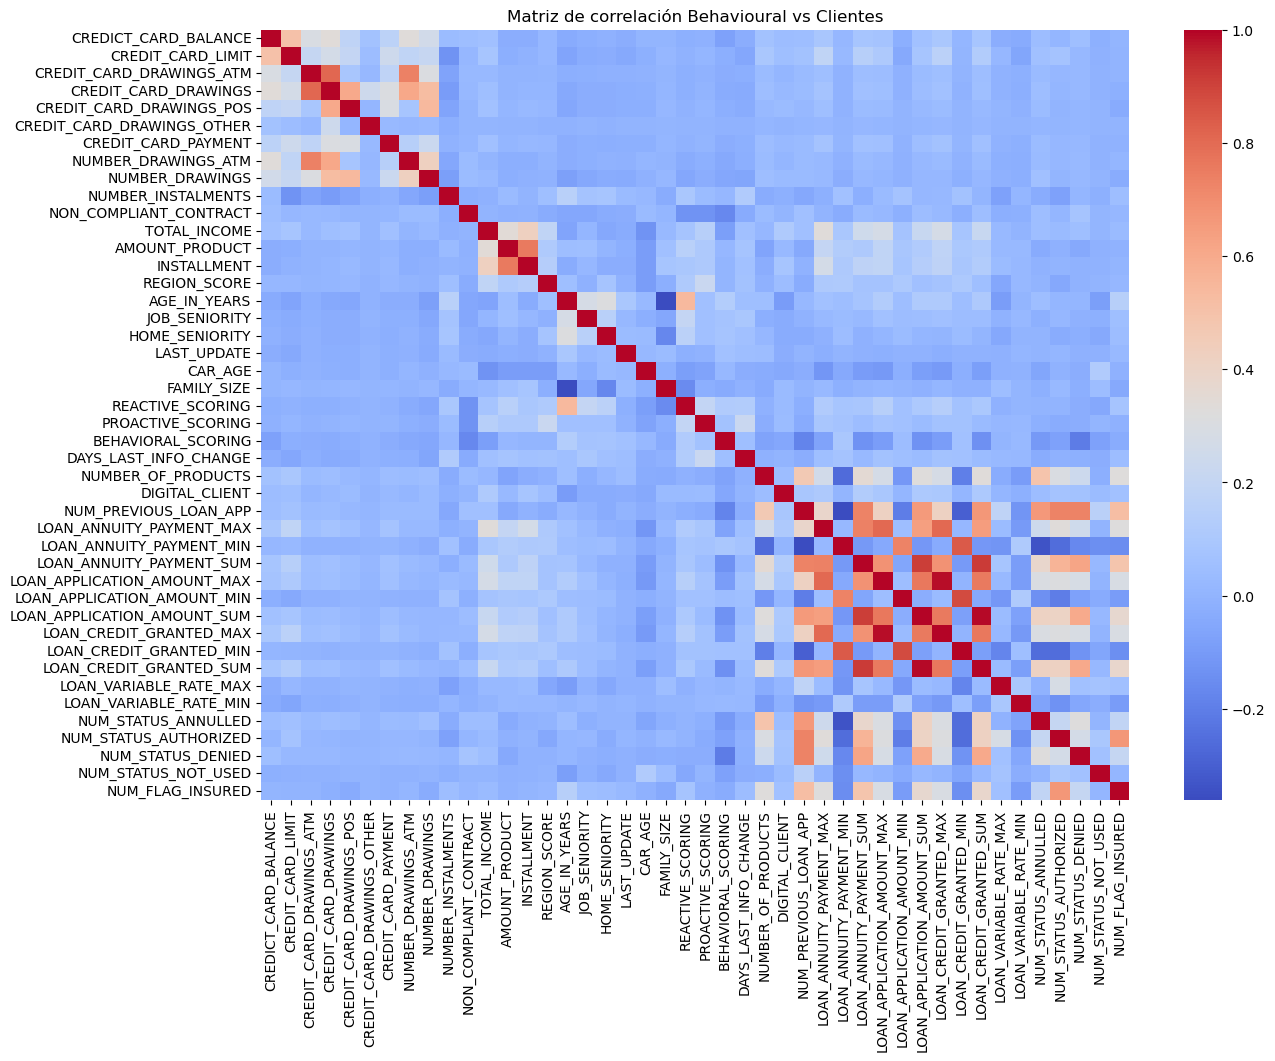

In [19]:
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Matriz de correlación Behavioural vs Clientes")
plt.show()

In [20]:
def interpretar_correlacion(r):
    r = abs(r)  # correlación en valor absoluto
    
    if 0.00 <= r <= 0.19:
        return "Muy baja correlación"
    elif 0.20 <= r <= 0.39:
        return "Baja correlación"
    elif 0.40 <= r <= 0.59:
        return "Correlación moderada"
    elif 0.60 <= r <= 0.79:
        return "Alta correlación"
    elif 0.80 <= r <= 1.00:
        return "Muy alta correlación"
    else:
        return "Valor fuera de rango"


In [21]:
corr_interpretada = corr_matrix.applymap(interpretar_correlacion)
corr_interpretada


,CREDICT_CARD_BALANCE,CREDIT_CARD_LIMIT,CREDIT_CARD_DRAWINGS_ATM,CREDIT_CARD_DRAWINGS,CREDIT_CARD_DRAWINGS_POS,CREDIT_CARD_DRAWINGS_OTHER,CREDIT_CARD_PAYMENT,NUMBER_DRAWINGS_ATM,NUMBER_DRAWINGS,NUMBER_INSTALMENTS,...,LOAN_CREDIT_GRANTED_MAX,LOAN_CREDIT_GRANTED_MIN,LOAN_CREDIT_GRANTED_SUM,LOAN_VARIABLE_RATE_MAX,LOAN_VARIABLE_RATE_MIN,NUM_STATUS_ANNULLED,NUM_STATUS_AUTHORIZED,NUM_STATUS_DENIED,NUM_STATUS_NOT_USED,NUM_FLAG_INSURED
CREDICT_CARD_BALANCE,Muy alta correlación,Correlación moderada,Baja correlación,Baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Baja correlación,Baja correlación,Muy baja correlación,...,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación
CREDIT_CARD_LIMIT,Correlación moderada,Muy alta correlación,Baja correlación,Baja correlación,Valor fuera de rango,Muy baja correlación,Baja correlación,Muy baja correlación,Baja correlación,Muy baja correlación,...,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación
CREDIT_CARD_DRAWINGS_ATM,Baja correlación,Baja correlación,Muy alta correlación,Muy alta correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Alta correlación,Baja correlación,Muy baja correlación,...,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación
CREDIT_CARD_DRAWINGS,Baja correlación,Baja correlación,Muy alta correlación,Muy alta correlación,Alta correlación,Baja correlación,Baja correlación,Alta correlación,Correlación moderada,Muy baja correlación,...,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación
CREDIT_CARD_DRAWINGS_POS,Muy baja correlación,Valor fuera de rango,Muy baja correlación,Alta correlación,Muy alta correlación,Muy baja correlación,Baja correlación,Muy baja correlación,Correlación moderada,Muy baja correlación,...,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación
CREDIT_CARD_DRAWINGS_OTHER,Muy baja correlación,Muy baja correlación,Muy baja correlación,Baja correlación,Muy baja correlación,Muy alta correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,...,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación
CREDIT_CARD_PAYMENT,Muy baja correlación,Baja correlación,Muy baja correlación,Baja correlación,Baja correlación,Muy baja correlación,Muy alta correlación,Muy baja correlación,Baja correlación,Muy baja correlación,...,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación
NUMBER_DRAWINGS_ATM,Baja correlación,Muy baja correlación,Alta correlación,Alta correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy alta correlación,Correlación moderada,Muy baja correlación,...,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación,Muy baja correlación
NUMBER_DRAWINGS,Baja correlación,Baja correlación,Baja correlación,Correlación moderada,Correlación moderada,Mu

In [22]:
# Categorías que SÍ queremos conservar
categorias_validas = [
    "Correlación moderada",
    "Alta correlación",
    "Muy alta correlación"
]

# Crear una copia filtrada
corr_filtrada = corr_interpretada.copy()

# Reemplazar todo lo que NO sea moderada/alta/muy alta por NaN
corr_filtrada = corr_filtrada.applymap(lambda x: x if x in categorias_validas else None)

# Eliminar filas y columnas completamente vacías
corr_filtrada = corr_filtrada.dropna(how="all")
corr_filtrada = corr_filtrada.dropna(axis=1, how="all")

corr_filtrada


,CREDICT_CARD_BALANCE,CREDIT_CARD_LIMIT,CREDIT_CARD_DRAWINGS_ATM,CREDIT_CARD_DRAWINGS,CREDIT_CARD_DRAWINGS_POS,CREDIT_CARD_DRAWINGS_OTHER,CREDIT_CARD_PAYMENT,NUMBER_DRAWINGS_ATM,NUMBER_DRAWINGS,NUMBER_INSTALMENTS,...,LOAN_CREDIT_GRANTED_MAX,LOAN_CREDIT_GRANTED_MIN,LOAN_CREDIT_GRANTED_SUM,LOAN_VARIABLE_RATE_MAX,LOAN_VARIABLE_RATE_MIN,NUM_STATUS_ANNULLED,NUM_STATUS_AUTHORIZED,NUM_STATUS_DENIED,NUM_STATUS_NOT_USED,NUM_FLAG_INSURED
CREDICT_CARD_BALANCE,Muy alta correlación,Correlación moderada,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
CREDIT_CARD_LIMIT,Correlación moderada,Muy alta correlación,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
CREDIT_CARD_DRAWINGS_ATM,None,None,Muy alta correlación,Muy alta correlación,None,None,None,Alta correlación,None,None,...,None,None,None,None,None,None,None,None,None,None
CREDIT_CARD_DRAWINGS,None,None,Muy alta correlación,Muy alta correlación,Alta correlación,None,None,Alta correlación,Correlación moderada,None,...,None,None,None,None,None,None,None,None,None,None
CREDIT_CARD_DRAWINGS_POS,None,None,None,Alta correlación,Muy alta correlación,None,None,None,Correlación moderada,None,...,None,None,None,None,None,None,None,None,None,None
CREDIT_CARD_DRAWINGS_OTHER,None,None,None,None,None,Muy alta correlación,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
CREDIT_CARD_PAYMENT,None,None,None,None,None,None,Muy alta correlación,None,None,None,...,None,None,None,None,None,None,None,None,None,None
NUMBER_DRAWINGS_ATM,None,None,Alta correlación,Alta correlación,None,None,None,Muy alta correlación,Correlación moderada,None,...,None,None,None,None,None,None,None,None,None,None
NUMBER_DRAWINGS,None,None,None,Correlación moderada,Correlación moderada,None,None,Correlación moderada,Muy alta correlación,None,...,None,None,None,None,None,None,None,None,None,None
NUMBER_INSTALMENTS,None,None,None,None,None,None,None,None,None,Muy alta correlación,...,None,None,None,None,None,None,None,None,None,None
